# 47 — LSEG/Gemma story-revision delta strategy

**Question.** Do strictly pre-open changes in Gemma sentiment across Reuters
story revisions contain directional information beyond the latest headline
level?

**Why this is distinct.** Notebook 43 asked whether deleting later revisions
rescued an existing all-headline rule. This notebook instead treats the change
from a family's first headline to each later revision as the signal. It uses
LSEG's vendor family metadata and the complete 888,155-headline Gemma score
population without emitting headline text or raw story identifiers.

**Frozen before returns.** Use the immutable original 33 companies. For each
family revision, compute `current Gemma score − first-release Gemma score`,
retain only companies associated with both endpoints, map the current revision
to the first open at least 15 minutes later, and keep the latest transition per
family/company/open. Average changes within firm-open. Long improving and short
deteriorating firms for one open-to-open interval, with equal legs, a 25%
single-name cap, unused capacity in cash, and 10 bps per traded side. The
matched comparator uses the same dates, names, long/short counts, gross
exposure, and costs but ranks the latest score level instead of the revision
delta.

The return-free gate requires at least 500 changed-headline transitions, 500
nonzero firm-open updates, 40 sessions with both signs, at least 20 such
sessions in each chronological half, and exact compliance with the 25% cap.
Net revision-delta return versus cash and versus the matched latest-level arm
form one two-test BH family. A stricter factor-alpha diagnostic spans the
equal-weight original-33 market and ten independent sector-minus-market
returns. The LSEG return window is already open, so even a passing result is a
retrospective candidate rather than validated or deployable alpha.

In [1]:
from __future__ import annotations

import json
import math
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import Markdown, display
from statsmodels.stats.multitest import multipletests

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "final_experiments":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.evaluate import annualized_sharpe  # noqa: E402
from final_experiments.lib.lseg_expanded import (  # noqa: E402
    load_price_exports,
    load_success_scores,
)
from final_experiments.lib.lseg_story_families import (  # noqa: E402
    load_family_revision_transitions,
)
from final_experiments.lib.plots import CATEGORICAL, INK, apply_house_style  # noqa: E402
from final_experiments.lib.risk_overlay import (  # noqa: E402
    paired_block_bootstrap_difference,
)
from final_experiments.lib.sector_portfolios import SECTOR_MEMBERS  # noqa: E402
from final_experiments.lib.sparse_spread import (  # noqa: E402
    build_exact_extrema_targets,
    ledger_rows_to_frame,
)
from sentiment_benchmark.artifact_io import sha256_file  # noqa: E402
from sentiment_benchmark.strategy_research.ledger import (  # noqa: E402
    run_open_to_open_ledger,
)
from sentiment_benchmark.strategy_research.market import OpenToOpenReturn  # noqa: E402
from sentiment_benchmark.strategy_research.portfolio import (  # noqa: E402
    PositionTarget,
    TargetPortfolio,
)

SEED = 20260817
COST_BPS = 10.0
COST_GRID = (0.0, 1.0, 2.0, 5.0, 10.0)
BLOCK_LENGTH = 5
REPLICATIONS = 9_999
SINGLE_NAME_CAP = 0.25
INITIAL_NAV = 1_000_000.0
MIN_TRANSITIONS = 500
MIN_FIRM_OPENS = 500
MIN_ACTIVE_SESSIONS = 40
MIN_HALF_ACTIVE_SESSIONS = 20

COLLECTION_DIR = REPO_ROOT / "Data/collections/lseg_us_sector_44_8m_headlines/derived"
GEMMA_PATH = (
    COLLECTION_DIR
    / "headline_scores_gemma4_26b_a4b_it_deepinfra_fp8_investor_headline_soft_label_v1.csv"
)
MERGED_HEADLINES = COLLECTION_DIR / "merged/headlines.jsonl"
AGGREGATE_PANEL = (
    REPO_ROOT
    / "final_experiments/outputs/13_lseg_44_gemma_robustness"
    / "gemma4_26b_firm_open_aggregators.parquet"
)
NOTEBOOK43_MANIFEST = (
    REPO_ROOT
    / "final_experiments/outputs/43_lseg_gemma_story_family_first_release/manifest.json"
)
PRICE_PATHS = (
    REPO_ROOT / "Data/derived/prices/lseg_us_sector_33_8m.csv",
    REPO_ROOT / "Data/derived/prices/lseg_us_sector_add11_8m.csv",
)
OUTPUT_DIR = (
    REPO_ROOT / "final_experiments/outputs/47_lseg_gemma_story_revision_delta"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SECTOR_MEMBERS_33 = {
    sector: tuple(members[:3]) for sector, members in SECTOR_MEMBERS.items()
}
ORIGINAL_SYMBOLS = tuple(
    sorted(symbol for members in SECTOR_MEMBERS_33.values() for symbol in members)
)
SECTOR_BY_SYMBOL = {
    symbol: sector
    for sector, members in SECTOR_MEMBERS_33.items()
    for symbol in members
}

apply_house_style()
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

## Licence-safe family transitions and score changes

No price or return value is loaded in this section. The family helper reads
local licensed text only to recreate the existing normalized hash. It returns
hashes, timestamps, revision numbers, and shared company symbols—never text or
raw vendor story identifiers. Only aggregate counts are displayed.

In [2]:
notebook43 = json.loads(NOTEBOOK43_MANIFEST.read_text(encoding="utf-8"))
if notebook43.get("status") != "RETROSPECTIVE_STORY_FAMILY_NO_GO":
    raise ValueError("Notebook 43 family contract is not the frozen completed run")

gemma_scores, score_audit = load_success_scores(GEMMA_PATH, scorer="gemma4_26b")
transitions, family_audit = load_family_revision_transitions(
    MERGED_HEADLINES,
    expected_hashes=set(gemma_scores["headline_sha256"]),
)
score_map = gemma_scores.set_index("headline_sha256")["score"]
transitions["initial_score"] = transitions["initial_headline_sha256"].map(score_map)
transitions["current_score"] = transitions["current_headline_sha256"].map(score_map)
if transitions[["initial_score", "current_score"]].isna().any().any():
    raise RuntimeError("family transition score join is incomplete")
transitions["score_delta"] = transitions["current_score"] - transitions["initial_score"]
transitions = transitions.loc[
    transitions["headline_changed"] & transitions["shared_symbols"].ne("")
].copy()
eligible_transition_rows = len(transitions)

transition_summary = pd.DataFrame(
    [
        {
            "successful_gemma_hashes": score_audit["unique_successes"],
            "story_families": family_audit["story_families_in_score_population"],
            "multirow_families": family_audit["families_with_multiple_rows"],
            "all_later_revision_rows": family_audit["transition_rows"],
            "changed_headline_shared_symbol_transitions": eligible_transition_rows,
            "minimum_required_transitions": MIN_TRANSITIONS,
            "licensed_headline_text_emitted": False,
            "raw_story_ids_emitted": False,
        }
    ]
)
display(transition_summary.T)

,0
successful_gemma_hashes,888155
story_families,1149954
multirow_families,3638
all_later_revision_rows,8742
changed_headline_shared_symbol_transitions,8654
minimum_required_transitions,500
licensed_headline_text_emitted,False
raw_story_ids_emitted,False


## Strictly pre-open firm-open revision signal

Only `symbol` and `session_date` are read from the price exports here. The
transition timestamp plus the frozen 15-minute buffer determines the entry
open. Multiple revisions from one family mapping to the same company/open are
collapsed to the latest available state before averaging across families.

In [3]:
calendar = pd.concat(
    [pd.read_csv(path, usecols=["symbol", "session_date"]) for path in PRICE_PATHS],
    ignore_index=True,
)
calendar["symbol"] = calendar["symbol"].astype(str)
calendar["session_date"] = pd.to_datetime(calendar["session_date"]).dt.normalize()
if calendar.duplicated(["symbol", "session_date"]).any():
    raise ValueError("price calendar has duplicate company-session rows")

calendar_sessions = pd.DatetimeIndex(
    sorted(calendar["session_date"].unique())
).as_unit("ns")
open_utc = (
    calendar_sessions.tz_localize("America/New_York") + np.timedelta64(570, "m")
).tz_convert("UTC")
cutoffs = pd.DatetimeIndex(pd.to_datetime(transitions["revision_timestamp"], utc=True))
cutoffs = cutoffs + np.timedelta64(15, "m")
positions = open_utc.searchsorted(cutoffs, side="left")
valid = positions < len(calendar_sessions)
transitions = transitions.loc[valid].copy()
transitions["entry_session"] = calendar_sessions.take(positions[valid]).to_numpy()
transitions["symbol"] = transitions["shared_symbols"].str.split("|")
transitions = transitions.explode("symbol", ignore_index=True)
transitions["symbol"] = transitions["symbol"].astype(str)
transitions = transitions.loc[transitions["symbol"].isin(ORIGINAL_SYMBOLS)].copy()
transitions = transitions.sort_values(
    [
        "story_family_sha256",
        "symbol",
        "entry_session",
        "revision_timestamp",
        "current_revision_number",
        "current_headline_sha256",
    ],
    kind="mergesort",
).drop_duplicates(
    ["story_family_sha256", "symbol", "entry_session"], keep="last"
)

firm_open = (
    transitions.groupby(["entry_session", "symbol"], as_index=False)
    .agg(
        mean_revision_delta=("score_delta", "mean"),
        mean_latest_score=("current_score", "mean"),
        story_family_updates=("story_family_sha256", "nunique"),
    )
    .rename(columns={"entry_session": "session_date"})
)
firm_open = firm_open.loc[firm_open["mean_revision_delta"].abs().gt(1e-12)].copy()

signal_grid = pd.read_parquet(AGGREGATE_PANEL, columns=["session_date", "symbol"])
signal_grid["session_date"] = pd.to_datetime(signal_grid["session_date"]).dt.normalize()
signal_grid["symbol"] = signal_grid["symbol"].astype(str)
signal_grid = signal_grid.loc[signal_grid["symbol"].isin(ORIGINAL_SYMBOLS)].copy()
if signal_grid.duplicated(["session_date", "symbol"]).any():
    raise ValueError("aggregate scorer grid has duplicate company-session rows")
sessions = pd.DatetimeIndex(sorted(signal_grid["session_date"].unique()))
if len(sessions) != 167 or not signal_grid.groupby("session_date")["symbol"].nunique().eq(33).all():
    raise ValueError("expected the complete immutable 33 by 167 input grid")
firm_open = firm_open.loc[firm_open["session_date"].isin(sessions)].copy()
signal_grid = signal_grid.merge(
    firm_open,
    on=["session_date", "symbol"],
    how="left",
    validate="one_to_one",
)
signal_grid["revision_sign"] = np.sign(signal_grid["mean_revision_delta"])

## Frozen revision-delta and matched latest-level targets

The revision arm trades every nonzero mean change when both signs are present.
The matched comparator preserves the exact active dates, number of names on
each leg, feasible leg exposure, and company set, but assigns the long and
short legs by the latest score level. Alphabetical symbol order resolves ties.

In [4]:
delta_targets, delta_target_audit = build_exact_extrema_targets(
    signal_grid,
    signal_col="revision_sign",
    single_name_cap=SINGLE_NAME_CAP,
)


def build_matched_level_targets(
    panel: pd.DataFrame,
    delta_audit: pd.DataFrame,
    ordered_symbols: tuple[str, ...],
) -> tuple[tuple[TargetPortfolio, ...], pd.DataFrame]:
    targets: list[TargetPortfolio] = []
    audit_rows: list[dict[str, object]] = []
    for row in delta_audit.itertuples(index=False):
        session = pd.Timestamp(row.session_date)
        n_long = int(row.positive_names)
        n_short = int(row.negative_names)
        eligible = bool(row.eligible)
        day = panel.loc[
            panel["session_date"].eq(session) & panel["revision_sign"].notna(),
            ["symbol", "mean_latest_score"],
        ].sort_values(
            ["mean_latest_score", "symbol"],
            ascending=[False, True],
            kind="mergesort",
        )
        long_symbols: set[str] = set()
        short_symbols: set[str] = set()
        leg_exposure = 0.0
        if eligible:
            if len(day) != n_long + n_short:
                raise RuntimeError("matched level universe does not equal nonzero delta names")
            long_symbols = set(day.head(n_long)["symbol"])
            short_symbols = set(day.tail(n_short)["symbol"])
            if not long_symbols or not short_symbols or long_symbols & short_symbols:
                raise RuntimeError("matched level legs are invalid")
            leg_exposure = float(row.leg_exposure)
        weights = {
            symbol: (
                leg_exposure / n_long
                if symbol in long_symbols
                else -leg_exposure / n_short
                if symbol in short_symbols
                else 0.0
            )
            for symbol in ordered_symbols
        }
        vector = np.asarray([weights[symbol] for symbol in ordered_symbols], dtype=float)
        if abs(vector.sum()) > 1e-12 or np.abs(vector).max() > SINGLE_NAME_CAP + 1e-12:
            raise RuntimeError("matched level target violates exposure constraints")
        positions = tuple(
            PositionTarget(
                symbol=symbol,
                action=(
                    1.0
                    if symbol in long_symbols
                    else -1.0
                    if symbol in short_symbols
                    else 0.0
                ),
                volatility=None,
                raw_weight=float(weights[symbol]),
                target_weight=float(weights[symbol]),
                exclusion_reason=None,
            )
            for symbol in ordered_symbols
        )
        targets.append(
            TargetPortfolio(
                session=str(session.date()),
                positions=positions,
                gross_exposure=float(np.abs(vector).sum()),
                net_exposure=float(vector.sum()),
                long_exposure=float(vector[vector > 0].sum()),
                short_exposure=float(-vector[vector < 0].sum()),
                cash_weight=1.0 - float(vector.sum()),
            )
        )
        delta_long = set(
            panel.loc[
                panel["session_date"].eq(session) & panel["revision_sign"].eq(1.0),
                "symbol",
            ]
        )
        delta_short = set(
            panel.loc[
                panel["session_date"].eq(session) & panel["revision_sign"].eq(-1.0),
                "symbol",
            ]
        )
        delta_names = delta_long | delta_short if eligible else set()
        matched_names = long_symbols | short_symbols
        audit_rows.append(
            {
                "session_date": session,
                "eligible": eligible,
                "long_names": n_long,
                "short_names": n_short,
                "gross_exposure": float(np.abs(vector).sum()),
                "delta_vs_level_long_jaccard": (
                    len(delta_long & long_symbols) / len(delta_long | long_symbols)
                    if delta_long | long_symbols
                    else 1.0
                ),
                "delta_vs_level_short_jaccard": (
                    len(delta_short & short_symbols) / len(delta_short | short_symbols)
                    if delta_short | short_symbols
                    else 1.0
                ),
                "same_traded_name_set": delta_names == matched_names,
            }
        )
    return tuple(targets), pd.DataFrame(audit_rows)


level_targets, level_target_audit = build_matched_level_targets(
    signal_grid,
    delta_target_audit,
    ORIGINAL_SYMBOLS,
)
if not delta_target_audit["eligible"].equals(level_target_audit["eligible"]):
    raise RuntimeError("matched comparator changed activity")
if not np.allclose(
    delta_target_audit["gross_exposure"],
    level_target_audit["gross_exposure"],
    atol=1e-12,
):
    raise RuntimeError("matched comparator changed gross exposure")
if not level_target_audit["same_traded_name_set"].all():
    raise RuntimeError("matched comparator changed the eligible company set")

midpoint = sessions[len(sessions) // 2]
active_dates = pd.DatetimeIndex(
    delta_target_audit.loc[delta_target_audit["eligible"], "session_date"]
)
input_summary = pd.DataFrame(
    [
        {
            "eligible_transition_rows": eligible_transition_rows,
            "original33_transition_associations": len(transitions),
            "nonzero_firm_open_updates": len(firm_open),
            "update_sessions": int(firm_open["session_date"].nunique()),
            "both_sign_active_sessions": int(delta_target_audit["eligible"].sum()),
            "first_half_active_sessions": int((active_dates < midpoint).sum()),
            "second_half_active_sessions": int((active_dates >= midpoint).sum()),
            "median_positive_names": float(
                delta_target_audit.loc[
                    delta_target_audit["eligible"], "positive_names"
                ].median()
            ),
            "median_negative_names": float(
                delta_target_audit.loc[
                    delta_target_audit["eligible"], "negative_names"
                ].median()
            ),
            "mean_target_gross_exposure": float(
                delta_target_audit["gross_exposure"].mean()
            ),
            "maximum_name_weight": float(
                delta_target_audit["max_abs_name_weight"].max()
            ),
            "median_long_name_jaccard_vs_latest_level": float(
                level_target_audit.loc[
                    level_target_audit["eligible"], "delta_vs_level_long_jaccard"
                ].median()
            ),
            "median_short_name_jaccard_vs_latest_level": float(
                level_target_audit.loc[
                    level_target_audit["eligible"], "delta_vs_level_short_jaccard"
                ].median()
            ),
        }
    ]
)
input_gate = bool(
    eligible_transition_rows >= MIN_TRANSITIONS
    and len(firm_open) >= MIN_FIRM_OPENS
    and input_summary.loc[0, "both_sign_active_sessions"] >= MIN_ACTIVE_SESSIONS
    and input_summary.loc[0, "first_half_active_sessions"] >= MIN_HALF_ACTIVE_SESSIONS
    and input_summary.loc[0, "second_half_active_sessions"] >= MIN_HALF_ACTIVE_SESSIONS
    and input_summary.loc[0, "maximum_name_weight"] <= SINGLE_NAME_CAP + 1e-12
)
input_summary["return_free_feasibility_gate"] = input_gate
display(input_summary.T)
if not input_gate:
    raise RuntimeError("revision-delta strategy stopped at the return-free feasibility gate")

,0
eligible_transition_rows,8654
original33_transition_associations,3819
nonzero_firm_open_updates,1606
update_sessions,167
both_sign_active_sessions,165
first_half_active_sessions,82
second_half_active_sessions,83
median_positive_names,5.000000
median_negative_names,5.000000
mean_target_gross_exposure,0.934132


## Open the already-used LSEG return window once

Only after the input gate passes are split-adjusted opens loaded. Recomputed
next-open returns must match Notebook 13's aggregate original-33 return column
to numerical tolerance. Every signal session must have a complete next open.

In [5]:
prices = load_price_exports(*PRICE_PATHS, expected_symbols=44)
prices = prices.loc[prices["symbol"].isin(ORIGINAL_SYMBOLS)].copy()
open_wide = (
    prices.pivot(index="session_date", columns="symbol", values="adjusted_open")
    .sort_index()
    .dropna()
)
locations = open_wide.index.get_indexer(sessions)
if (locations < 0).any() or not np.array_equal(locations[1:], locations[:-1] + 1):
    raise ValueError("signal sessions are not consecutive complete-price sessions")
if locations[-1] + 1 >= len(open_wide):
    raise ValueError("last signal session has no next complete open")

return_rows: list[OpenToOpenReturn] = []
return_matrix_rows: list[np.ndarray] = []
recomputed_rows: list[dict[str, object]] = []
for session, location in zip(sessions, locations, strict=True):
    next_session = open_wide.index[location + 1]
    values = (
        open_wide.loc[next_session, list(ORIGINAL_SYMBOLS)]
        / open_wide.loc[session, list(ORIGINAL_SYMBOLS)]
        - 1.0
    )
    return_matrix_rows.append(values.to_numpy(dtype=float))
    for symbol, value in values.items():
        return_rows.append(
            OpenToOpenReturn(
                symbol=symbol,
                session=str(session.date()),
                next_session=str(next_session.date()),
                value=float(value),
            )
        )
        recomputed_rows.append(
            {
                "session_date": session,
                "symbol": symbol,
                "recomputed_raw_open_h1": float(value),
            }
        )
return_matrix = np.vstack(return_matrix_rows)

stored_returns = pd.read_parquet(
    AGGREGATE_PANEL,
    columns=["session_date", "symbol", "raw_open_h1"],
)
stored_returns["session_date"] = pd.to_datetime(
    stored_returns["session_date"]
).dt.normalize()
stored_returns = stored_returns.loc[
    stored_returns["symbol"].isin(ORIGINAL_SYMBOLS)
].copy()
return_audit = stored_returns.merge(
    pd.DataFrame(recomputed_rows),
    on=["session_date", "symbol"],
    validate="one_to_one",
)
return_audit["absolute_error"] = (
    return_audit["raw_open_h1"] - return_audit["recomputed_raw_open_h1"]
).abs()
if return_audit["absolute_error"].max() > 1e-12:
    raise RuntimeError("price-derived returns do not reproduce Notebook 13")

coverage = pd.DataFrame(
    [
        {
            "sessions": len(sessions),
            "companies": len(ORIGINAL_SYMBOLS),
            "active_sessions": int(delta_target_audit["eligible"].sum()),
            "first_entry_session": sessions.min(),
            "last_entry_session": sessions.max(),
            "last_return_end": open_wide.index[locations[-1] + 1],
            "max_return_reproduction_error": float(
                return_audit["absolute_error"].max()
            ),
            "missing_return_cells": int((~np.isfinite(return_matrix)).sum()),
        }
    ]
)
display(coverage.T)

,0
sessions,167
companies,33
active_sessions,165
first_entry_session,2025-10-27 00:00:00
last_entry_session,2026-06-26 00:00:00
last_return_end,2026-06-29 00:00:00
max_return_reproduction_error,0.000000
missing_return_cells,0


## Drift-aware accounting, costs, and paired inference

The ledger marks weights against after-cost NAV, charges every rebalance, and
folds one forced final liquidation into the last interval. The two primary
comparisons form one BH family; positive estimates favour revision delta.

In [6]:
def fold_final_liquidation(frame: pd.DataFrame) -> pd.DataFrame:
    liquidation = frame.loc[frame["final_liquidation"]]
    intervals = frame.loc[~frame["final_liquidation"]].copy().reset_index(drop=True)
    if len(liquidation) != 1 or intervals.empty:
        raise RuntimeError("expected one terminal liquidation after non-empty intervals")
    final = liquidation.iloc[0]
    last = intervals.index[-1]
    intervals.loc[last, "net_return"] = (
        (1.0 + intervals.loc[last, "net_return"]) * (1.0 + final["net_return"])
        - 1.0
    )
    intervals.loc[last, "turnover"] += final["turnover"]
    intervals.loc[last, "cost"] += final["cost"]
    intervals.loc[last, "end_nav"] = final["end_nav"]
    return intervals


def run_targets(
    targets: tuple[TargetPortfolio, ...],
    returns: list[OpenToOpenReturn],
    *,
    cost_bps: float,
) -> pd.DataFrame:
    full = ledger_rows_to_frame(
        run_open_to_open_ledger(
            targets,
            returns,
            cost_rate_per_side=cost_bps / 10_000.0,
            initial_nav_usd=INITIAL_NAV,
            force_final_liquidation=True,
        )
    )
    return fold_final_liquidation(full)


def summarize_path(daily: pd.DataFrame, *, cost_bps: float) -> dict[str, float | int]:
    gross = daily["gross_return"].to_numpy(dtype=float)
    net = daily["net_return"].to_numpy(dtype=float)
    gross_equity = np.cumprod(1.0 + gross)
    net_equity = np.cumprod(1.0 + net)
    with_start = np.r_[1.0, net_equity]
    turnover = float(daily["turnover"].sum())
    return {
        "n_sessions": int(len(daily)),
        "active_sessions": int(daily["gross_exposure"].gt(0).sum()),
        "mean_gross": float(gross.mean()),
        "mean_net": float(net.mean()),
        "sharpe_gross": annualized_sharpe(pd.Series(gross)),
        "sharpe_net": annualized_sharpe(pd.Series(net)),
        "ann_vol_net": float(np.std(net, ddof=1) * math.sqrt(252)),
        "total_return_gross": float(gross_equity[-1] - 1.0),
        "total_return_net": float(net_equity[-1] - 1.0),
        "max_drawdown": float(
            np.min(with_start / np.maximum.accumulate(with_start) - 1.0)
        ),
        "mean_turnover": float(turnover / len(daily)),
        "total_turnover": turnover,
        "mean_gross_exposure": float(daily["gross_exposure"].mean()),
        "max_abs_net_exposure": float(daily["net_exposure"].abs().max()),
        "breakeven_bps_per_side": float(10_000.0 * gross.sum() / turnover),
        "cost_bps_per_side": cost_bps,
    }


target_arms = {
    "revision_delta": delta_targets,
    "matched_latest_level": level_targets,
}
daily_paths = {
    arm: run_targets(targets, return_rows, cost_bps=COST_BPS)
    for arm, targets in target_arms.items()
}
results = pd.DataFrame(
    [
        {"arm": arm, **summarize_path(daily, cost_bps=COST_BPS)}
        for arm, daily in daily_paths.items()
    ]
)
if not np.allclose(
    daily_paths["revision_delta"]["gross_exposure"],
    daily_paths["matched_latest_level"]["gross_exposure"],
    atol=1e-12,
):
    raise RuntimeError("matched latest-level path changed gross exposure")

cash = daily_paths["revision_delta"][["session_date"]].copy()
cash["net_return"] = 0.0
comparison_specs = (
    ("revision_delta_minus_cash", cash),
    ("revision_delta_minus_matched_latest_level", daily_paths["matched_latest_level"]),
)
inference_rows = []
for offset, (comparison, baseline) in enumerate(comparison_specs):
    inference_rows.append(
        {
            "comparison": comparison,
            **paired_block_bootstrap_difference(
                daily_paths["revision_delta"],
                baseline,
                value_col="net_return",
                block_length=BLOCK_LENGTH,
                replications=REPLICATIONS,
                seed=SEED + offset,
            ),
        }
    )
inference = pd.DataFrame(inference_rows)
_, inference["q_bh_two_test"], _, _ = multipletests(
    inference["p_two_sided"], alpha=0.05, method="fdr_bh"
)
inference["bh_reject_q05"] = inference["q_bh_two_test"].lt(0.05)
inference["multiplicity_family"] = (
    "revision delta versus cash and matched latest level; BH-FDR q=0.05"
)
display(results.T)
display(inference)

,0,1
arm,revision_delta,matched_latest_level
n_sessions,167,167
active_sessions,165,165
mean_gross,0.000673,-0.000943
mean_net,-0.000827,-0.002389
sharpe_gross,1.522514,-1.983474
sharpe_net,-1.865725,-5.004380
ann_vol_net,0.111669,0.120290
total_return_gross,0.114297,-0.149814
total_return_net,-0.132581,-0.332480


,comparison,n_sessions,mean_difference,ci_low,ci_high,p_two_sided,block_length,replications,seed,q_bh_two_test,bh_reject_q05,multiplicity_family
0,revision_delta_minus_cash,167,-0.000827,-0.001790,0.000120,0.091400,5,9999,20260817,0.091400,False,revision delta versus cash and matched latest ...
1,revision_delta_minus_matched_latest_level,167,0.001562,0.000268,0.002873,0.018400,5,9999,20260818,0.036800,True,revision delta versus cash and matched latest ...


## Cost sensitivity and independently initialized halves

No parameter is re-estimated. Each half starts from cash and pays its own
terminal liquidation cost.

In [7]:
cost_rows = []
for cost in COST_GRID:
    for arm, targets in target_arms.items():
        path = run_targets(targets, return_rows, cost_bps=cost)
        cost_rows.append({"arm": arm, **summarize_path(path, cost_bps=cost)})
cost_curve = pd.DataFrame(cost_rows)

half_indices = {
    "first_half": sessions[: len(sessions) // 2],
    "second_half": sessions[len(sessions) // 2 :],
}
temporal_rows = []
for period, half_sessions in half_indices.items():
    session_strings = {str(session.date()) for session in half_sessions}
    half_returns = [row for row in return_rows if row.session in session_strings]
    for arm, targets in target_arms.items():
        half_targets = tuple(
            target for target in targets if target.session in session_strings
        )
        path = run_targets(half_targets, half_returns, cost_bps=COST_BPS)
        temporal_rows.append(
            {"period": period, "arm": arm, **summarize_path(path, cost_bps=COST_BPS)}
        )
temporal = pd.DataFrame(temporal_rows)
display(cost_curve)
display(temporal)

,arm,n_sessions,active_sessions,mean_gross,mean_net,sharpe_gross,sharpe_net,ann_vol_net,total_return_gross,total_return_net,max_drawdown,mean_turnover,total_turnover,mean_gross_exposure,max_abs_net_exposure,breakeven_bps_per_side,cost_bps_per_side
0,revision_delta,167,165,0.000673,0.000673,1.522514,1.522514,0.111333,0.114297,0.114297,-0.042613,1.498207,250.200623,0.934132,0.000000,4.489643,0.000000
1,matched_latest_level,167,165,-0.000943,-0.000943,-1.983474,-1.983474,0.119822,-0.149814,-0.149814,-0.150697,1.444755,241.274136,0.934132,0.000000,-6.527811,0.000000
2,revision_delta,167,165,0.000673,0.000523,1.522514,1.183092,0.111358,0.114297,0.086772,-0.044221,1.498320,250.219506,0.934132,0.000000,4.489304,1.000000
3,matched_latest_level,167,165,-0.000943,-0.001088,-1.983474,-2.286590,0.119860,-0.149814,-0.170106,-0.170885,1.444860,241.291537,0.934132,0.000000,-6.527340,1.000000
4,revision_delta,167,165,0.000673,0.000373,1.522514,0.843755,0.111384,0.114297,0.059920,-0.048821,1.498434,250.238397,0.934132,0.000000,4.488965,2.000000
5,matched_latest_level,167,165,-0.000943,-0.001232,-1.983474,-2.589515,0.119901,-0.149814,-0.189918,-0.190598,1.444964,241.308965,0.934132,0.000000,-6.526869,2.000000
6,revision_delta,167,165,0.000673,-0.000077,1.522514,-0.173560,0.111477,0.114297,-0.016767,-0.075968,1.498773,250.295122,0.934132,0.000000,4.487947,5.000000
7,matched_latest_level,167,165,-0.000943,-0.001666,-1.983474,-3.497005,0.120033,-0.149814,-0.246596,-0.247002,1.445278,241.361349,0.934132,0.000000,-6.525452,5.000000
8,revision_delta,167,165,0.000673,-0.000827,1.522514,-1.865725,0.111669,0.114297,-0.132581,-0.167732,1.499342,250.390193,0.934132,0.000000,4.486243,10.000000
9,matched_latest_level,167,165,-0.000943,-0.002389,-1.983474,-5.004380,0.120290,-0.149814,-0.332480,-0.332506,1.445803,241.449066,0.934132,0.000000,-6.523082,10.000000


,period,arm,n_sessions,active_sessions,mean_gross,mean_net,sharpe_gross,sharpe_net,ann_vol_net,total_return_gross,total_return_net,max_drawdown,mean_turnover,total_turnover,mean_gross_exposure,max_abs_net_exposure,breakeven_bps_per_side,cost_bps_per_side
0,first_half,revision_delta,83,82,0.000608,-0.000872,1.655109,-2.353523,0.093352,0.050262,-0.071155,-0.102875,1.479592,122.806147,0.921687,0.000000,4.107621,10.000000
1,first_half,matched_latest_level,83,82,-0.000553,-0.001980,-1.471110,-5.222451,0.095564,-0.046244,-0.152982,-0.159087,1.427792,118.506697,0.921687,0.000000,-3.871081,10.000000
2,second_half,revision_delta,84,83,0.000737,-0.000790,1.452950,-1.557266,0.127841,0.060970,-0.066746,-0.100869,1.526642,128.237889,0.946429,0.000000,4.825955,10.000000
3,second_half,matched_latest_level,84,83,-0.001329,-0.002800,-2.380913,-5.009652,0.140849,-0.108592,-0.212432,-0.212432,1.471365,123.594626,0.946429,0.000000,-9.031484,10.000000


## Static market and sector-factor intercepts

The sector-spanning model uses the original-33 equal-weight market plus ten
sector-minus-market returns. Omitting the alphabetically last sector removes
the one linear dependency while spanning all eleven sector portfolios.

In [8]:
factor_panel = pd.DataFrame({"session_date": sessions})
factor_panel["equal_weight_market"] = return_matrix.mean(axis=1)
symbol_index = {symbol: index for index, symbol in enumerate(ORIGINAL_SYMBOLS)}
sector_names = tuple(sorted(SECTOR_MEMBERS_33))
for sector in sector_names:
    indices = [symbol_index[symbol] for symbol in SECTOR_MEMBERS_33[sector]]
    factor_panel[f"sector_{sector}"] = return_matrix[:, indices].mean(axis=1)
spread_columns = []
for sector in sector_names[:-1]:
    column = f"spread_{sector}"
    factor_panel[column] = (
        factor_panel[f"sector_{sector}"] - factor_panel["equal_weight_market"]
    )
    spread_columns.append(column)

regression = daily_paths["revision_delta"][["session_date", "net_return"]].merge(
    factor_panel,
    on="session_date",
    validate="one_to_one",
)
model_specs = {
    "constant_only": [],
    "market_only": ["equal_weight_market"],
    "sector_spanning": ["equal_weight_market", *spread_columns],
}
factor_rows = []
for model_name, columns in model_specs.items():
    design = sm.add_constant(regression[columns], has_constant="add")
    if np.linalg.matrix_rank(design.to_numpy(dtype=float)) != design.shape[1]:
        raise RuntimeError(f"factor design is rank deficient for {model_name}")
    fit = sm.OLS(regression["net_return"], design).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": BLOCK_LENGTH, "use_correction": True},
    )
    interval = fit.conf_int(alpha=0.05).loc["const"]
    factor_rows.append(
        {
            "model": model_name,
            "n_sessions": int(fit.nobs),
            "n_factors": len(columns),
            "alpha_bps_session": float(fit.params["const"] * 10_000),
            "alpha_ci_low_bps_session": float(interval.iloc[0] * 10_000),
            "alpha_ci_high_bps_session": float(interval.iloc[1] * 10_000),
            "alpha_t_hac5": float(fit.tvalues["const"]),
            "alpha_p_two_sided_hac5": float(fit.pvalues["const"]),
            "r_squared": float(fit.rsquared),
            "market_beta": float(fit.params.get("equal_weight_market", np.nan)),
        }
    )
factor_models = pd.DataFrame(factor_rows)
display(factor_models)

,model,n_sessions,n_factors,alpha_bps_session,alpha_ci_low_bps_session,alpha_ci_high_bps_session,alpha_t_hac5,alpha_p_two_sided_hac5,r_squared,market_beta
0,constant_only,167,0,-8.267608,-17.837945,1.302729,-1.693171,0.090423,0.000000,NaN
1,market_only,167,1,-8.802405,-18.197599,0.592790,-1.836300,0.066313,0.005460,0.073254
2,sector_spanning,167,11,-9.208052,-19.128909,0.712805,-1.819142,0.068890,0.052128,0.150031


## Company and sector dependence

Each leave-one-out replay removes the company or sector, rebuilds both sign
counts and feasible leg exposure, and reruns the same costed strategy. These
are dependence diagnostics, not subset selectors.

In [9]:
def replay_subset(remaining: tuple[str, ...]) -> dict[str, float | int]:
    reduced_panel = signal_grid.loc[signal_grid["symbol"].isin(remaining)].copy()
    reduced_targets, _ = build_exact_extrema_targets(
        reduced_panel,
        signal_col="revision_sign",
        single_name_cap=SINGLE_NAME_CAP,
    )
    keep = set(remaining)
    reduced_returns = [row for row in return_rows if row.symbol in keep]
    reduced_daily = run_targets(reduced_targets, reduced_returns, cost_bps=COST_BPS)
    return summarize_path(reduced_daily, cost_bps=COST_BPS)


company_loo = pd.DataFrame(
    [
        {
            "removed_symbol": symbol,
            **replay_subset(tuple(item for item in ORIGINAL_SYMBOLS if item != symbol)),
        }
        for symbol in ORIGINAL_SYMBOLS
    ]
).sort_values("sharpe_net", ignore_index=True)

sector_rows = []
for sector, removed_symbols in SECTOR_MEMBERS_33.items():
    removed = set(removed_symbols)
    remaining = tuple(symbol for symbol in ORIGINAL_SYMBOLS if symbol not in removed)
    sector_rows.append({"removed_sector": sector, **replay_subset(remaining)})
sector_loo = pd.DataFrame(sector_rows).sort_values("sharpe_net", ignore_index=True)

delta_weight_matrix = np.vstack(
    [
        np.asarray(
            [target.weights()[symbol] for symbol in ORIGINAL_SYMBOLS], dtype=float
        )
        for target in delta_targets
    ]
)
gross_contribution = (delta_weight_matrix * return_matrix).sum(axis=0)
attribution = pd.DataFrame(
    {
        "symbol": ORIGINAL_SYMBOLS,
        "sector": [SECTOR_BY_SYMBOL[symbol] for symbol in ORIGINAL_SYMBOLS],
        "gross_contribution": gross_contribution,
        "active_sessions": (np.abs(delta_weight_matrix) > 1e-12).sum(axis=0),
    }
).sort_values("gross_contribution", ascending=False, ignore_index=True)
gross_total = float(attribution["gross_contribution"].sum())
attribution["share_of_total_gross"] = (
    attribution["gross_contribution"] / gross_total if gross_total else np.nan
)
dependence = pd.DataFrame(
    [
        {
            "company_replays": len(company_loo),
            "positive_company_replays": int(company_loo["total_return_net"].gt(0).sum()),
            "minimum_company_loo_sharpe": float(company_loo["sharpe_net"].min()),
            "median_company_loo_sharpe": float(company_loo["sharpe_net"].median()),
            "sector_replays": len(sector_loo),
            "positive_sector_replays": int(sector_loo["total_return_net"].gt(0).sum()),
            "minimum_sector_loo_sharpe": float(sector_loo["sharpe_net"].min()),
            "median_sector_loo_sharpe": float(sector_loo["sharpe_net"].median()),
            "largest_abs_company_gross_contribution": float(
                attribution["gross_contribution"].abs().max()
            ),
        }
    ]
)
display(attribution.head(10))
display(dependence.T)

,symbol,sector,gross_contribution,active_sessions,share_of_total_gross
0,BA,industrials,0.043112,88,0.383792
1,GOOGL,communication_services,0.021609,115,0.192371
2,TSLA,consumer_discretionary,0.017411,80,0.154993
3,AMZN,consumer_discretionary,0.017320,105,0.154185
4,CVX,energy,0.013158,92,0.117138
5,DUK,utilities,0.009146,21,0.081423
6,BAC,financials,0.008846,48,0.078751
7,FCX,materials,0.008829,17,0.078595
8,PLD,real_estate,0.008173,7,0.072756
9,HD,consumer_discretionary,0.008076,7,0.071892


,0
company_replays,33.000000
positive_company_replays,0.000000
minimum_company_loo_sharpe,-2.184039
median_company_loo_sharpe,-1.872542
sector_replays,11.000000
positive_sector_replays,0.000000
minimum_sector_loo_sharpe,-2.361106
median_sector_loo_sharpe,-1.835082
largest_abs_company_gross_contribution,0.043112


## Frozen gates

A full retrospective strategy pass requires cash alpha, incremental return
beyond latest-level ranking, economic/temporal quality, factor alpha, and
broad leave-one-out support. No gate can promote this already-opened window.

In [10]:
result_index = results.set_index("arm")
revision_result = result_index.loc["revision_delta"]
inference_index = inference.set_index("comparison")
cash_test = inference_index.loc["revision_delta_minus_cash"]
level_test = inference_index.loc["revision_delta_minus_matched_latest_level"]
temporal_index = temporal.set_index(["period", "arm"])
half_sharpes = {
    period: float(temporal_index.loc[(period, "revision_delta"), "sharpe_net"])
    for period in half_indices
}
sector_factor = factor_models.set_index("model").loc["sector_spanning"]

cash_alpha_gate = bool(cash_test["ci_low"] > 0 and cash_test["bh_reject_q05"])
incremental_revision_gate = bool(
    level_test["ci_low"] > 0 and level_test["bh_reject_q05"]
)
strategy_quality_gate = bool(
    revision_result["active_sessions"] >= 60
    and revision_result["sharpe_net"] >= 0.75
    and revision_result["breakeven_bps_per_side"] > COST_BPS
    and all(value >= 0 for value in half_sharpes.values())
    and input_summary.loc[0, "maximum_name_weight"] <= SINGLE_NAME_CAP + 1e-12
)
factor_alpha_gate = bool(
    sector_factor["alpha_ci_low_bps_session"] > 0
    and sector_factor["alpha_p_two_sided_hac5"] < 0.05
)
dependence_quality_gate = bool(
    dependence.loc[0, "positive_company_replays"] == dependence.loc[0, "company_replays"]
    and dependence.loc[0, "positive_sector_replays"] == dependence.loc[0, "sector_replays"]
    and dependence.loc[0, "minimum_company_loo_sharpe"] > 0
    and dependence.loc[0, "minimum_sector_loo_sharpe"] > 0
)
retrospective_strategy_gate = bool(
    cash_alpha_gate
    and incremental_revision_gate
    and strategy_quality_gate
    and factor_alpha_gate
    and dependence_quality_gate
)
gates = pd.DataFrame(
    [
        {
            "return_free_feasibility_gate": input_gate,
            "cash_alpha_gate": cash_alpha_gate,
            "incremental_revision_gate": incremental_revision_gate,
            "strategy_quality_gate": strategy_quality_gate,
            "factor_alpha_gate": factor_alpha_gate,
            "dependence_quality_gate": dependence_quality_gate,
            "retrospective_strategy_gate": retrospective_strategy_gate,
            "revision_net_sharpe": float(revision_result["sharpe_net"]),
            "revision_total_return_net": float(revision_result["total_return_net"]),
            "revision_breakeven_bps_per_side": float(
                revision_result["breakeven_bps_per_side"]
            ),
            "revision_minus_cash_bps_session": float(
                cash_test["mean_difference"] * 10_000
            ),
            "revision_minus_cash_ci_low_bps_session": float(
                cash_test["ci_low"] * 10_000
            ),
            "revision_minus_cash_ci_high_bps_session": float(
                cash_test["ci_high"] * 10_000
            ),
            "revision_minus_cash_q_bh": float(cash_test["q_bh_two_test"]),
            "revision_minus_level_bps_session": float(
                level_test["mean_difference"] * 10_000
            ),
            "revision_minus_level_ci_low_bps_session": float(
                level_test["ci_low"] * 10_000
            ),
            "revision_minus_level_ci_high_bps_session": float(
                level_test["ci_high"] * 10_000
            ),
            "revision_minus_level_q_bh": float(level_test["q_bh_two_test"]),
            "sector_factor_alpha_bps_session": float(
                sector_factor["alpha_bps_session"]
            ),
            "sector_factor_ci_low_bps_session": float(
                sector_factor["alpha_ci_low_bps_session"]
            ),
            "sector_factor_ci_high_bps_session": float(
                sector_factor["alpha_ci_high_bps_session"]
            ),
            "sector_factor_p_two_sided": float(
                sector_factor["alpha_p_two_sided_hac5"]
            ),
            "first_half_net_sharpe": half_sharpes["first_half"],
            "second_half_net_sharpe": half_sharpes["second_half"],
        }
    ]
)
display(gates.T)

,0
return_free_feasibility_gate,True
cash_alpha_gate,False
incremental_revision_gate,True
strategy_quality_gate,False
factor_alpha_gate,False
dependence_quality_gate,False
retrospective_strategy_gate,False
revision_net_sharpe,-1.865725
revision_total_return_net,-0.132581
revision_breakeven_bps_per_side,4.486243


## Figures

findfont: Failed to find font weight medium, now using 400.


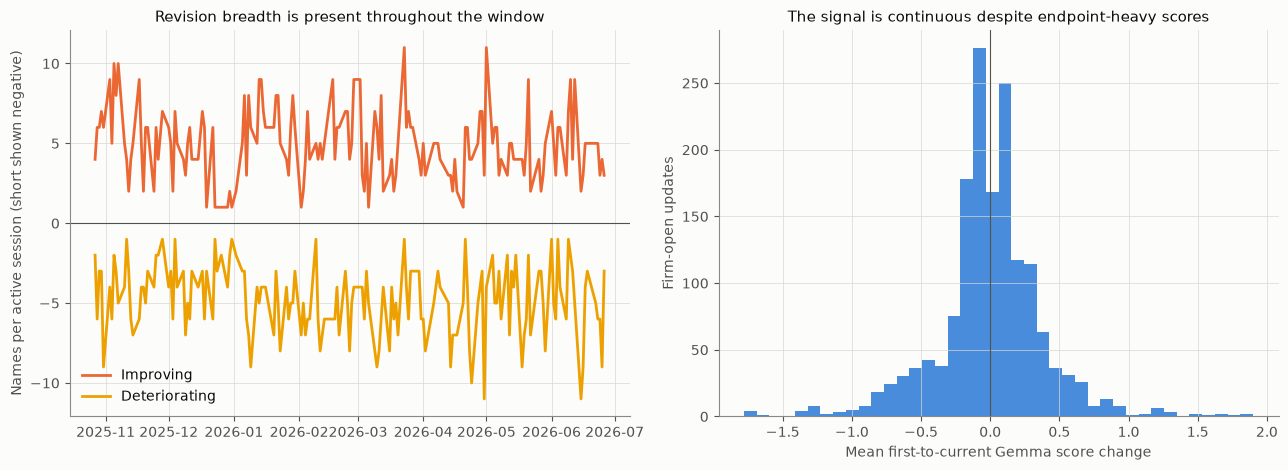

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
active_audit = delta_target_audit.loc[delta_target_audit["eligible"]]
axes[0].plot(
    active_audit["session_date"],
    active_audit["positive_names"],
    color=CATEGORICAL[1],
    label="Improving",
)
axes[0].plot(
    active_audit["session_date"],
    -active_audit["negative_names"],
    color=CATEGORICAL[3],
    label="Deteriorating",
)
axes[0].axhline(0.0, color=INK["reference"], linewidth=0.8)
axes[0].set_ylabel("Names per active session (short shown negative)")
axes[0].set_title("Revision breadth is present throughout the window")
axes[0].legend(loc="best")
axes[1].hist(
    firm_open["mean_revision_delta"],
    bins=40,
    color=CATEGORICAL[0],
    alpha=0.85,
)
axes[1].axvline(0.0, color=INK["reference"], linewidth=0.8)
axes[1].set_xlabel("Mean first-to-current Gemma score change")
axes[1].set_ylabel("Firm-open updates")
axes[1].set_title("The signal is continuous despite endpoint-heavy scores")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "revision_signal_breadth.png", dpi=170, bbox_inches="tight")
plt.show()

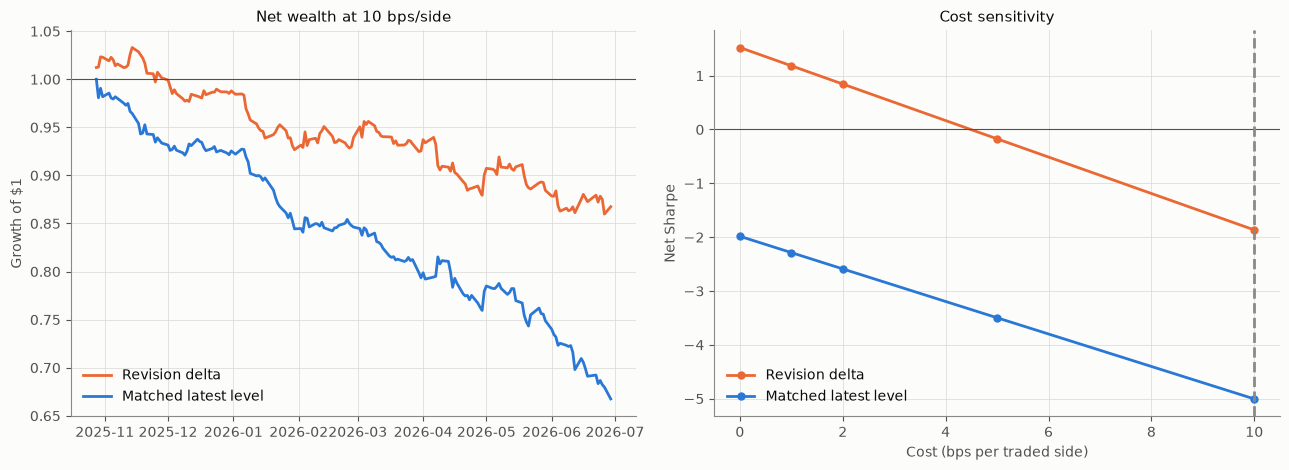

In [12]:
labels = {
    "revision_delta": "Revision delta",
    "matched_latest_level": "Matched latest level",
}
colours = {
    "revision_delta": CATEGORICAL[1],
    "matched_latest_level": CATEGORICAL[0],
}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for arm, daily in daily_paths.items():
    axes[0].plot(
        daily["return_end_date"],
        (1.0 + daily["net_return"]).cumprod(),
        color=colours[arm],
        label=labels[arm],
    )
axes[0].axhline(1.0, color=INK["reference"], linewidth=0.8)
axes[0].set_ylabel("Growth of $1")
axes[0].set_title("Net wealth at 10 bps/side")
axes[0].legend(loc="best")
for arm in target_arms:
    line = cost_curve.loc[cost_curve["arm"].eq(arm)]
    axes[1].plot(
        line["cost_bps_per_side"],
        line["sharpe_net"],
        marker="o",
        color=colours[arm],
        label=labels[arm],
    )
axes[1].axhline(0.0, color=INK["reference"], linewidth=0.8)
axes[1].axvline(COST_BPS, color=INK["muted"], linestyle="--")
axes[1].set_xlabel("Cost (bps per traded side)")
axes[1].set_ylabel("Net Sharpe")
axes[1].set_title("Cost sensitivity")
axes[1].legend(loc="best")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "equity_and_cost.png", dpi=170, bbox_inches="tight")
plt.show()

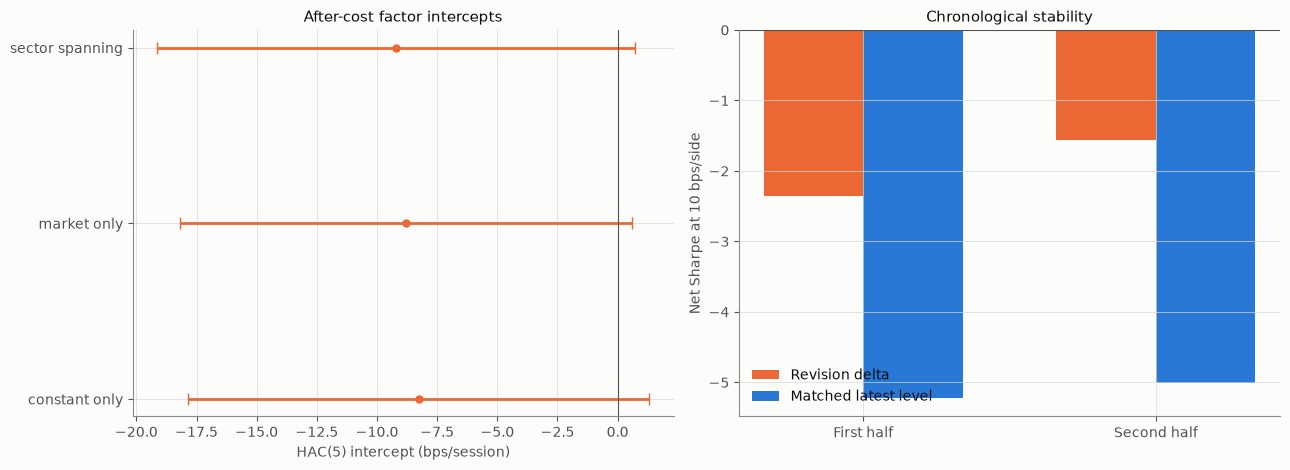

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
models = factor_models.set_index("model").loc[list(model_specs)]
y = np.arange(len(models))
axes[0].errorbar(
    models["alpha_bps_session"],
    y,
    xerr=np.vstack(
        [
            models["alpha_bps_session"] - models["alpha_ci_low_bps_session"],
            models["alpha_ci_high_bps_session"] - models["alpha_bps_session"],
        ]
    ),
    fmt="o",
    color=CATEGORICAL[1],
    capsize=4,
)
axes[0].axvline(0.0, color=INK["reference"], linewidth=0.8)
axes[0].set_yticks(y, [name.replace("_", " ") for name in models.index])
axes[0].set_xlabel("HAC(5) intercept (bps/session)")
axes[0].set_title("After-cost factor intercepts")
half_plot = temporal.pivot(index="period", columns="arm", values="sharpe_net").reindex(
    ["first_half", "second_half"]
)
x = np.arange(len(half_plot))
width = 0.34
for offset, arm in enumerate(target_arms):
    axes[1].bar(
        x + (offset - 0.5) * width,
        half_plot[arm],
        width,
        color=colours[arm],
        label=labels[arm],
    )
axes[1].axhline(0.0, color=INK["reference"], linewidth=0.8)
axes[1].set_xticks(x, ["First half", "Second half"])
axes[1].set_ylabel("Net Sharpe at 10 bps/side")
axes[1].set_title("Chronological stability")
axes[1].legend(loc="best")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "factor_and_temporal.png", dpi=170, bbox_inches="tight")
plt.show()

## Persist aggregate evidence and decision

In [14]:
transition_summary.to_csv(OUTPUT_DIR / "transition_summary.csv", index=False)
input_summary.to_csv(OUTPUT_DIR / "input_summary.csv", index=False)
firm_open.to_parquet(OUTPUT_DIR / "firm_open_revision_signals.parquet", index=False)
delta_target_audit.to_csv(OUTPUT_DIR / "delta_target_audit.csv", index=False)
level_target_audit.to_csv(OUTPUT_DIR / "matched_level_target_audit.csv", index=False)
coverage.to_csv(OUTPUT_DIR / "coverage.csv", index=False)
results.to_csv(OUTPUT_DIR / "results.csv", index=False)
inference.to_csv(OUTPUT_DIR / "inference.csv", index=False)
cost_curve.to_csv(OUTPUT_DIR / "cost_curve.csv", index=False)
temporal.to_csv(OUTPUT_DIR / "temporal.csv", index=False)
factor_models.to_csv(OUTPUT_DIR / "factor_models.csv", index=False)
company_loo.to_csv(OUTPUT_DIR / "leave_one_company_out.csv", index=False)
sector_loo.to_csv(OUTPUT_DIR / "leave_one_sector_out.csv", index=False)
attribution.to_csv(OUTPUT_DIR / "company_attribution.csv", index=False)
dependence.to_csv(OUTPUT_DIR / "dependence_summary.csv", index=False)
gates.to_csv(OUTPUT_DIR / "gates.csv", index=False)
for arm, daily in daily_paths.items():
    daily.to_parquet(OUTPUT_DIR / f"{arm}_daily.parquet", index=False)

output_hashes = {
    name: sha256_file(OUTPUT_DIR / name)
    for name in (
        "firm_open_revision_signals.parquet",
        "delta_target_audit.csv",
        "results.csv",
        "inference.csv",
        "gates.csv",
    )
}

try:
    git_commit = subprocess.run(
        ["git", "rev-parse", "HEAD"],
        cwd=REPO_ROOT,
        check=True,
        capture_output=True,
        text=True,
    ).stdout.strip()
except (OSError, subprocess.CalledProcessError):
    git_commit = None

status = (
    "RETROSPECTIVE_REVISION_DELTA_ALL_GATES_PASS_NOT_VALIDATED"
    if retrospective_strategy_gate
    else "RETROSPECTIVE_REVISION_DELTA_NO_GO"
)
manifest = {
    "status": status,
    "notebook": "47_lseg_gemma_story_revision_delta.ipynb",
    "git_commit_at_execution": git_commit,
    "seed": SEED,
    "input": {
        "gemma_scores": str(GEMMA_PATH.relative_to(REPO_ROOT)),
        "gemma_scores_sha256": score_audit["output_sha256"],
        "merged_corpus": str(MERGED_HEADLINES.relative_to(REPO_ROOT)),
        "merged_corpus_sha256": family_audit["corpus_sha256"],
        "aggregate_session_grid": str(AGGREGATE_PANEL.relative_to(REPO_ROOT)),
        "aggregate_session_grid_sha256": sha256_file(AGGREGATE_PANEL),
        "notebook43_manifest": str(NOTEBOOK43_MANIFEST.relative_to(REPO_ROOT)),
        "notebook43_manifest_sha256": sha256_file(NOTEBOOK43_MANIFEST),
        "licensed_headline_text_emitted": False,
        "raw_story_ids_emitted": False,
        "returns_loaded_only_after_input_gate": True,
    },
    "return_free_input": json.loads(input_summary.to_json(orient="records"))[0],
    "specification": {
        "universe": "immutable original 33 LSEG companies",
        "signal": "mean current-minus-first Gemma score within family/company/open",
        "association": "company must be present in first and current family revisions",
        "deduplication": "latest transition per family/company/entry open",
        "information_buffer_minutes": 15,
        "long": "strictly positive mean revision delta",
        "short": "strictly negative mean revision delta",
        "matched_comparator": "same dates, firms, counts and gross; latest-score rank",
        "single_name_cap": SINGLE_NAME_CAP,
        "gross_exposure": 1.0,
        "holding_intervals": 1,
        "cost_bps_per_traded_side": COST_BPS,
        "block_inference": f"{REPLICATIONS} five-session circular-block replications",
        "multiplicity": "two return comparisons; BH-FDR q=0.05",
        "factor_control": "HAC(5) market plus ten sector-minus-market returns",
        "final_liquidation": True,
    },
    "results": json.loads(results.to_json(orient="records")),
    "inference": json.loads(inference.to_json(orient="records")),
    "factor_models": json.loads(factor_models.to_json(orient="records")),
    "dependence": json.loads(dependence.to_json(orient="records"))[0],
    "gates": json.loads(gates.to_json(orient="records"))[0],
    "output_hashes": output_hashes,
    "limitations": [
        "the 2025-2026 LSEG outcome window was opened repeatedly before this test",
        "Notebook 43 motivated revision metadata as a bounded post-result direction",
        "vendor story-family syntax and revision behaviour may not transfer to other feeds",
        "headline-level Gemma accuracy on the licensed population lacks human validation",
        "the latest-level comparator is matched on activity and capacity, not on score scale",
        "sector factors are contemporaneous internal equal-weight benchmarks",
        "prices are split adjusted but not dividend adjusted",
        "no result can be promoted before Gate F1 or called deployable alpha",
    ],
}
(OUTPUT_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2) + "\n")
print(json.dumps(manifest, indent=2))

{
  "status": "RETROSPECTIVE_REVISION_DELTA_NO_GO",
  "notebook": "47_lseg_gemma_story_revision_delta.ipynb",
  "git_commit_at_execution": "d781284254ca6f0bd47c30cf68afa9aa458aaf5d",
  "seed": 20260817,
  "input": {
    "gemma_scores": "Data/collections/lseg_us_sector_44_8m_headlines/derived/headline_scores_gemma4_26b_a4b_it_deepinfra_fp8_investor_headline_soft_label_v1.csv",
    "gemma_scores_sha256": "afb2d9c3029c4fba4fce3600218233a02d14051788f87313fd49c9da681c6d2f",
    "merged_corpus": "Data/collections/lseg_us_sector_44_8m_headlines/derived/merged/headlines.jsonl",
    "merged_corpus_sha256": "7f48c46690f3293cbfe846ddecc701852daf3c35643f2747dcbc39f829927878",
    "aggregate_session_grid": "final_experiments/outputs/13_lseg_44_gemma_robustness/gemma4_26b_firm_open_aggregators.parquet",
    "aggregate_session_grid_sha256": "2fe436f1d75fce77c821cd6a05d4dbd4fa0473a0e7026400e2a90649003689a5",
    "notebook43_manifest": "final_experiments/outputs/43_lseg_gemma_story_family_first_release

## Decision

In [15]:
level_result = result_index.loc["matched_latest_level"]
decision = f"""
**{status.replace('_', ' ')}.** The return-free gate passes with
**{int(input_summary.loc[0, 'nonzero_firm_open_updates']):,}** nonzero firm-open
updates and **{int(input_summary.loc[0, 'both_sign_active_sessions'])}/167**
active sessions.

At 10 bps/side, revision delta has gross/net Sharpe
**{revision_result['sharpe_gross']:.3f}/{revision_result['sharpe_net']:.3f}**,
net return **{revision_result['total_return_net']:.2%}**, drawdown
**{revision_result['max_drawdown']:.2%}**, and break-even
**{revision_result['breakeven_bps_per_side']:.2f} bps/side**. The matched latest
level arm has net Sharpe **{level_result['sharpe_net']:.3f}** and net return
**{level_result['total_return_net']:.2%}**.

Revision delta minus cash is **{cash_test['mean_difference'] * 10_000:+.3f}
bps/session** with interval **[{cash_test['ci_low'] * 10_000:+.3f},
{cash_test['ci_high'] * 10_000:+.3f}]** and BH q=
**{cash_test['q_bh_two_test']:.4f}**. Revision delta minus the matched latest
level is **{level_test['mean_difference'] * 10_000:+.3f} bps/session** with
interval **[{level_test['ci_low'] * 10_000:+.3f},
{level_test['ci_high'] * 10_000:+.3f}]** and BH q=
**{level_test['q_bh_two_test']:.4f}**. Half Sharpes are
**{half_sharpes['first_half']:.3f}/{half_sharpes['second_half']:.3f}**. The
sector-spanning HAC alpha is **{sector_factor['alpha_bps_session']:+.3f}
bps/session** with interval **[{sector_factor['alpha_ci_low_bps_session']:+.3f},
{sector_factor['alpha_ci_high_bps_session']:+.3f}]**.

Cash alpha gate: **{cash_alpha_gate}**. Incremental revision-information gate:
**{incremental_revision_gate}**. Strategy-quality gate:
**{strategy_quality_gate}**. Factor-alpha gate: **{factor_alpha_gate}**.
Dependence-quality gate: **{dependence_quality_gate}**. Full retrospective gate:
**{retrospective_strategy_gate}**.

This is a single disclosed test of information in Reuters tone revisions. It is
not independent validation and cannot justify deployment or further tuning on
these 167 sessions.
"""
display(Markdown(decision))


**RETROSPECTIVE REVISION DELTA NO GO.** The return-free gate passes with
**1,606** nonzero firm-open
updates and **165/167**
active sessions.

At 10 bps/side, revision delta has gross/net Sharpe
**1.523/-1.866**,
net return **-13.26%**, drawdown
**-16.77%**, and break-even
**4.49 bps/side**. The matched latest
level arm has net Sharpe **-5.004** and net return
**-33.25%**.

Revision delta minus cash is **-8.268
bps/session** with interval **[-17.899,
+1.200]** and BH q=
**0.0914**. Revision delta minus the matched latest
level is **+15.620 bps/session** with
interval **[+2.683,
+28.725]** and BH q=
**0.0368**. Half Sharpes are
**-2.354/-1.557**. The
sector-spanning HAC alpha is **-9.208
bps/session** with interval **[-19.129,
+0.713]**.

Cash alpha gate: **False**. Incremental revision-information gate:
**True**. Strategy-quality gate:
**False**. Factor-alpha gate: **False**.
Dependence-quality gate: **False**. Full retrospective gate:
**False**.

This is a single disclosed test of information in Reuters tone revisions. It is
not independent validation and cannot justify deployment or further tuning on
these 167 sessions.
